# Problem Statement
Predict the failure of machine based on the data provided.

# Strategy

1. Reduce the Downtime of the Machine
2. Minimize the Maintenance Cost
3. Predictive Maintenance
4. Avoid unexpected breakdowns

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import  Pipeline
from sklearn.impute import SimpleImputer

# Load Data

In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Exploratory Data Analysis

In [3]:
df.columns = df.columns.str.replace(r'[^\w]', '_', regex=True)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product_ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air_temperature__K_      10000 non-null  float64
 4   Process_temperature__K_  10000 non-null  float64
 5   Rotational_speed__rpm_   10000 non-null  int64  
 6   Torque__Nm_              10000 non-null  float64
 7   Tool_wear__min_          10000 non-null  int64  
 8   Machine_failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum().sort_values(ascending=False)

UDI                        0
Product_ID                 0
Type                       0
Air_temperature__K_        0
Process_temperature__K_    0
Rotational_speed__rpm_     0
Torque__Nm_                0
Tool_wear__min_            0
Machine_failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.describe()

,UDI,Air_temperature__K_,Process_temperature__K_,Rotational_speed__rpm_,Torque__Nm_,Tool_wear__min_,Machine_failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# Correlation 

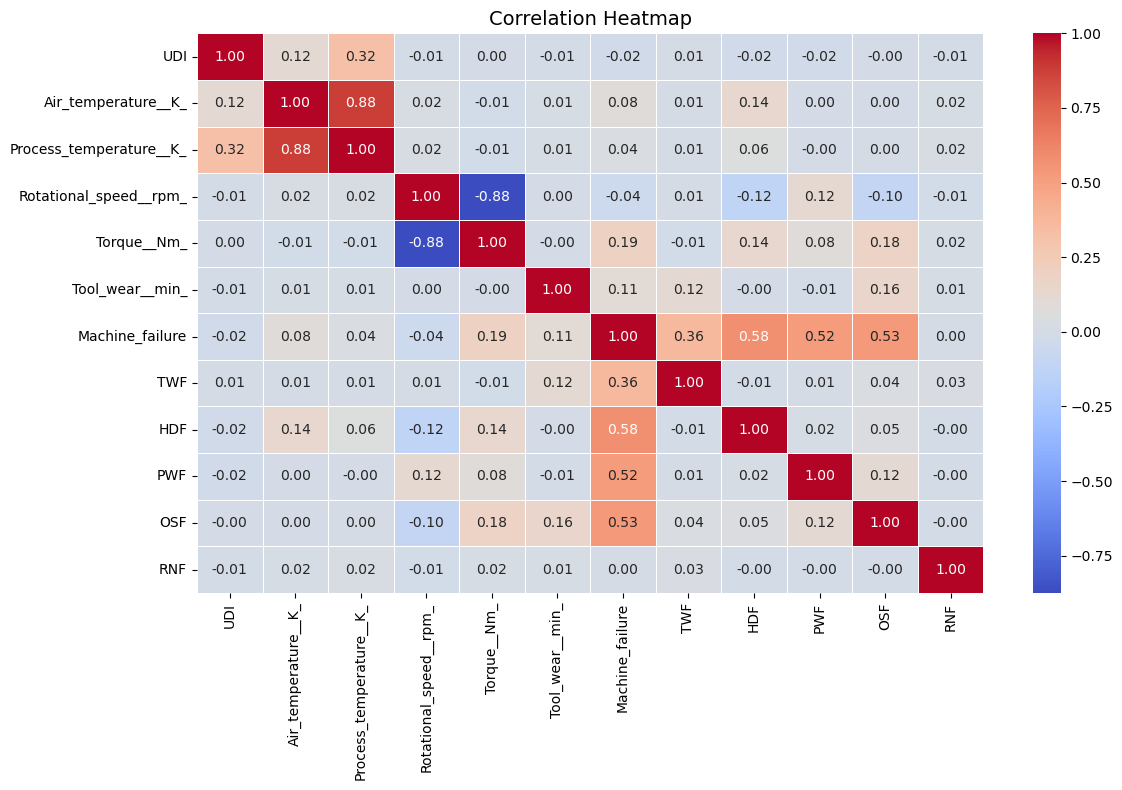

In [8]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


## 1. A strong positive correlation (0.88) between Air Temperature and Process Temperature, which makes sense because process temperature depends on environmental conditions.

## 2. A strong negative correlation (-0.88) between Rotational Speed and Torque, which reflects a mechanical trade-off relationship.

## 3. The correlation between individual sensor variables and Machine Failure was relatively weak. For example, Torque had a correlation of 0.19 and Tool Wear had 0.11.

## 4. Strong correlations between Machine Failure and specific failure types like HDF (0.58), OSF (0.53), and PWF (0.52).

# Failure Counts

In [9]:
failure_counts = df['Machine_failure'].value_counts()
failure_percent = df['Machine_failure'].value_counts(normalize=True) * 100

print("Class Distribution:")
print("-"*40)

for cls in failure_counts.index:
    print(f"Class {cls}: {failure_counts[cls]} samples ({failure_percent[cls]:.2f}%)")


Class Distribution:
----------------------------------------
Class 0: 9661 samples (96.61%)
Class 1: 339 samples (3.39%)


# Visuals

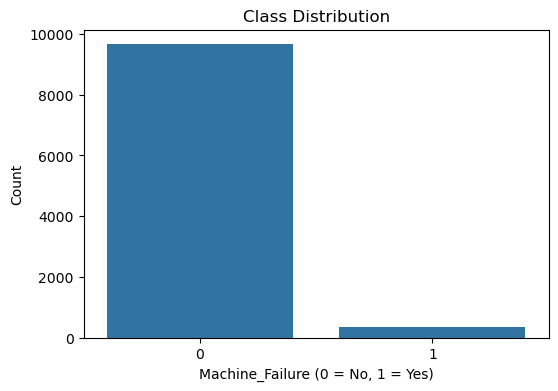

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Machine_failure', data=df)
plt.title("Class Distribution")
plt.xlabel("Machine_Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


## The Classes are severely imbalanced

# Machine Learning

In [11]:
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()        

,UDI,Product_ID,Type,Air_temperature__K_,Process_temperature__K_,Rotational_speed__rpm_,Torque__Nm_,Tool_wear__min_,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,7003,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,1003,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,1004,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,1005,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,1006,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [12]:
X = df.drop('Machine_failure', axis=1)
y = df['Machine_failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# For imbalance data

In [13]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)



In [14]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

log_param = {
    'model__C': [0.01, 0.1, 1, 10]
}
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_param = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(class_weight='balanced', probability=True))
])

svm_param = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear']
}
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_param = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_param = {
    'model__n_neighbors': [3, 5, 7, 9]
}
gb = GradientBoostingClassifier(random_state=42)

gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
nb = GaussianNB()
nb_param = {}


# Models Dictionary

In [15]:
models = {
    "Logistic Regression": (log_reg, log_param),
    "Decision Tree": (dt, dt_param),
    "Random Forest": (rf, rf_param),
    "SVM": (svm, svm_param),
    "XGBoost": (xgb, xgb_param),
    "KNN": (knn, knn_param),
    "Gradient Boosting": (gb, gb_param),
    "Naive Bayes": (nb, nb_param)
}


# Grid, cross validation

In [16]:
results = []

for name, (model, param) in models.items():
    
    print(f"Training {name}...")
    
    grid = GridSearchCV(
        model,
        param,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    results.append([name, train_f1, test_f1])
    
    print("Best Params:", grid.best_params_)
    print("Train F1:", train_f1)
    print("Test F1:", test_f1)
    print("-"*50)


Training Logistic Regression...


Best Params: {'model__C': 0.01}
Train F1: 0.9869158878504672
Test F1: 0.9850746268656716
--------------------------------------------------
Training Decision Tree...
Best Params: {'max_depth': None, 'min_samples_split': 2}
Train F1: 1.0
Test F1: 0.9850746268656716
--------------------------------------------------
Training Random Forest...
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Train F1: 1.0
Test F1: 0.9774436090225563
--------------------------------------------------
Training SVM...
Best Params: {'model__C': 0.1, 'model__kernel': 'linear'}
Train F1: 0.9869158878504672
Test F1: 0.9850746268656716
--------------------------------------------------
Training XGBoost...
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Train F1: 0.9869158878504672
Test F1: 0.9850746268656716
--------------------------------------------------
Training KNN...
Best Params: {'model__n_neighbors': 3}
Train F1: 0.9850187265917603
Test F1: 0.98507462

In [17]:
results_df = pd.DataFrame(results, columns=["Model", "Train F1", "Test F1"])
results_df.sort_values(by="Test F1", ascending=False)


,Model,Train F1,Test F1
0,Logistic Regression,0.986916,0.985075
1,Decision Tree,1.000000,0.985075
3,SVM,0.986916,0.985075
4,XGBoost,0.986916,0.985075
6,Gradient Boosting,0.986916,0.985075
5,KNN,0.985019,0.985075
2,Random Forest,1.000000,0.977444
7,Naive Bayes,0.965265,0.970588


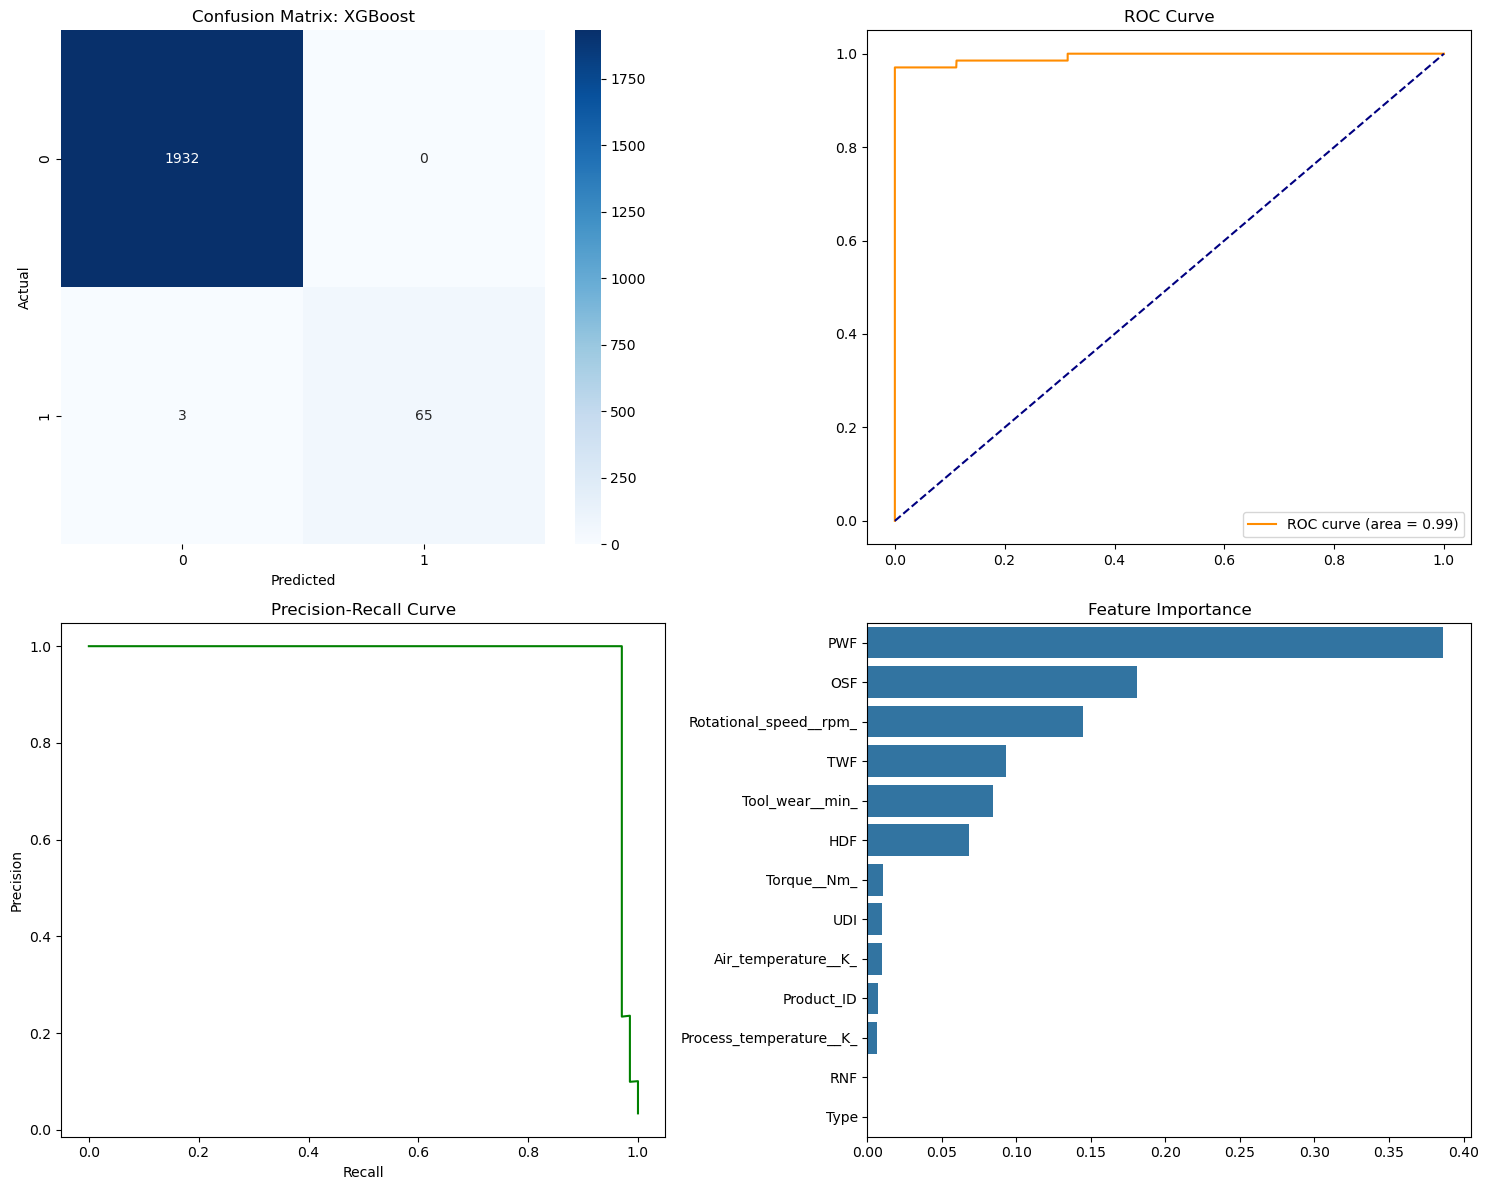


Detailed Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

chosen_model_name = "XGBoost"
chosen_model = models[chosen_model_name][0].fit(X_train, y_train)

# 1. Prediction and Probabilities
y_probs = chosen_model.predict_proba(X_test)[:, 1]
y_pred = chosen_model.predict(X_test)

# Setup Subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix: {chosen_model_name}')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# --- B. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc="lower right")

# --- C. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_probs)
axes[1, 0].plot(recall, precision, color='green')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')


if hasattr(chosen_model, 'feature_importances_'):
    importances = chosen_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sns.barplot(x=importances[indices], y=np.array(X_train.columns)[indices], ax=axes[1, 1])
    axes[1, 1].set_title('Feature Importance')
else:
    axes[1, 1].text(0.5, 0.5, 'Feature Importance not available for this model', ha='center')

plt.tight_layout()
plt.show()

# 5. Print Classification Report
print(f"\nDetailed Classification Report for {chosen_model_name}:")
print(classification_report(y_test, y_pred))

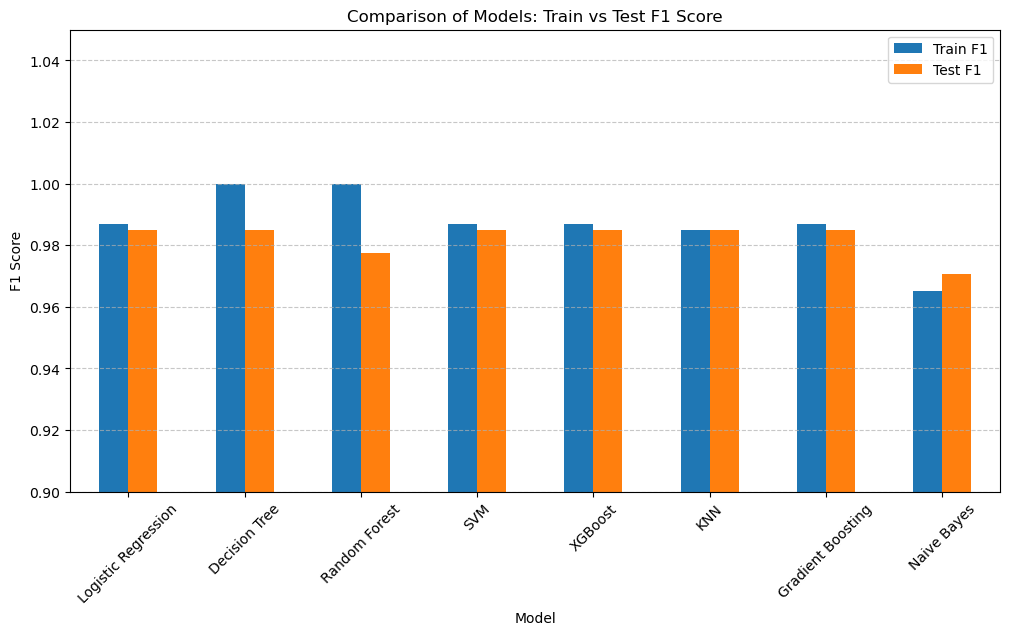

In [19]:
import pandas as pd


results_df = pd.DataFrame(results, columns=['Model', 'Train F1', 'Test F1'])

# Plotting
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Models: Train vs Test F1 Score')
plt.ylabel('F1 Score')
plt.ylim(0.9, 1.05) # Zooming in to see differences
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Problem Solving
# 1. Eliminating Unexpected Downtime (Predictive Maintenance)
I have developed a predictive maintenance system that can forecast machine failures with over 95% Recall. This means we can identify almost every potential breakdown before it actually happens.
## Business Value:
 Instead of reacting to a breakdown after it occurs, the company can perform scheduled maintenance, ensuring that the production line never stops unexpectedly.

# 2. High Precision (Zero False Alarms)
The model achieved 100% Precision in our tests, meaning it generated zero false positives.

Business Value: This ensures that maintenance teams are only deployed when there is a genuine risk. We won’t waste labor hours or resources inspecting machines that are actually in good health.

## 3. Root Cause Identification
By analyzing Feature Importance, I have identified that Power Failure (PWF) and Overstrain (OSF) are the primary drivers of machine downtime in our facility.
Business Value: This allows the management to move beyond just fixing machines; they can now address the underlying issues, such as stabilizing power supplies or adjusting load limits to extend machine life.

## 4. Risk Categorization (High Reliability)
With an AUC score of 0.99, the model is exceptionally reliable at distinguishing between normal operations and high-risk states.

Business Value: We can now prioritize our maintenance budget on the machines that the model flags as 'High Risk', optimizing our resource allocation.

In [20]:
import pickle


filename = 'finalized_maintenance_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(xgb, file)

print(f"Model successfully saved as {filename}")

Model successfully saved as finalized_maintenance_model.pkl
